In [ ]:
# Import Libraries
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/walkervs/online-gambling-ads-dataset-8k/data_cleaned_p2.csv")

# Load Dataset
X = df['komentar_cleaned_p1'].astype(str).tolist() 
y = df['label'].values

# Split Dataset (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

In [ ]:
# Initialize Tokenizer
tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p2')

# Encode data to id and attention mask
def encode_data(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

train_encoded = encode_data(X_train)
test_encoded = encode_data(X_test)

In [31]:
batch_size = 16

train_dataset = TensorDataset(train_encoded['input_ids'], train_encoded['attention_mask'], torch.tensor(y_train))
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)

test_dataset = TensorDataset(test_encoded['input_ids'], test_encoded['attention_mask'], torch.tensor(y_test))
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

In [ ]:
# set device to cuda if available, else cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    'indobenchmark/indobert-base-p2',
    num_labels=2
)
model.to(device)

# Optimizer & Scheduler
epochs = 3
optimizer = optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(train_dataloader) * epochs

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

In [ ]:
from transformers import get_linear_schedule_with_warmup

# create a scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [ ]:
import time

# Training mode
for epoch in range(epochs):
    print(f'\n======== Epoch {epoch + 1} / {epochs} ========')
    t0 = time.time()
    total_train_loss = 0

    model.train() 

    for step, batch in enumerate(train_dataloader):
        # Progress updated every 50 batches
        if step % 50 == 0 and not step == 0:
            print(f'  Batch {step}  of  {len(train_dataloader)}.')

        # Use GPU
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Clear gradients
        model.zero_grad()        

        # Forward pass
        outputs = model(b_input_ids, 
                        token_type_ids=None, 
                        attention_mask=b_input_mask, 
                        labels=b_labels)
        
        loss = outputs.loss
        total_train_loss += loss.item()

        # Backward pass (calculate gradient)
        loss.backward()

        # Clip gradient (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update weight & learning rate
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)            
    print(f"\n  Average training loss: {avg_train_loss:.2f}")
    print(f"  Training epoch took: {time.time() - t0:.2f}s")


======== Epoch 1 / 3 ========
  Batch 50  of  357.
  Batch 100  of  357.
  Batch 150  of  357.
  Batch 200  of  357.
  Batch 250  of  357.
  Batch 300  of  357.
  Batch 350  of  357.

  Average training loss: 0.14
  Training epoch took: 126.65s

======== Epoch 2 / 3 ========
  Batch 50  of  357.
  Batch 100  of  357.
  Batch 150  of  357.
  Batch 200  of  357.
  Batch 250  of  357.
  Batch 300  of  357.
  Batch 350  of  357.

  Average training loss: 0.04
  Training epoch took: 136.43s

======== Epoch 3 / 3 ========
  Batch 50  of  357.
  Batch 100  of  357.
  Batch 150  of  357.
  Batch 200  of  357.
  Batch 250  of  357.
  Batch 300  of  357.
  Batch 350  of  357.

  Average training loss: 0.01
  Training epoch took: 136.33s


[*] Mengevaluasi model pada data uji...

HASIL EVALUASI INDOBERT
              precision    recall  f1-score   support

  Bukan Judi       0.98      0.98      0.98      1224
  Iklan Judi       0.98      0.98      0.98      1223

    accuracy                           0.98      2447
   macro avg       0.98      0.98      0.98      2447
weighted avg       0.98      0.98      0.98      2447



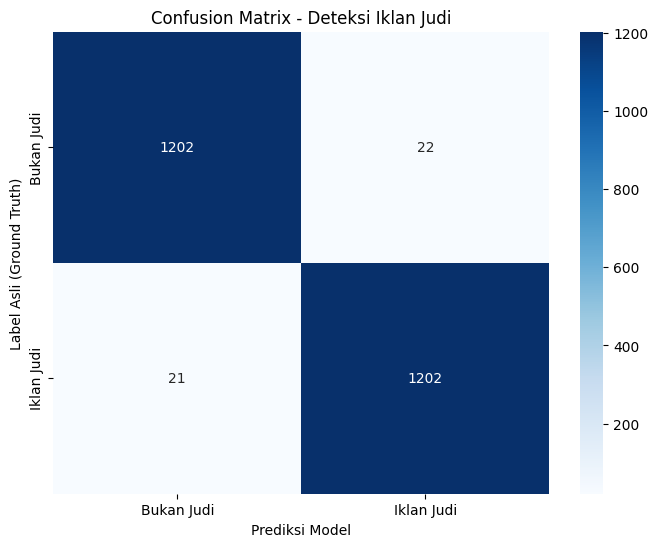

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Change mode to eval
model.eval()

all_preds = []
all_labels = []

# Get prediction from test_dataloader
print("[*] Mengevaluasi model pada data uji...")
for batch in test_dataloader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)
    
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    
    # Get logits and convert to 0 or 1
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1).flatten()
    
    # save results to list
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(b_labels.cpu().numpy())

# Evaluation
print("\n" + "="*30)
print("HASIL EVALUASI INDOBERT")
print("="*30)
print(classification_report(all_labels, all_preds, target_names=['Bukan Judi', 'Iklan Judi']))

# 4. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bukan Judi', 'Iklan Judi'], 
            yticklabels=['Bukan Judi', 'Iklan Judi'])
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli (Ground Truth)')
plt.title('Confusion Matrix - Deteksi Iklan Judi')
plt.show()

In [ ]:
import os

output_dir = '/kaggle/working/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save model and tokenizer
print(f"[*] Menyimpan model ke {output_dir}...")
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("[DONE] Model berhasil dikonversi dan disimpan!")

[*] Menyimpan model ke /kaggle/working/...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[DONE] Model berhasil dikonversi dan disimpan!


In [37]:
def normalize_all_cases(text):
    if not isinstance(text, str): return ""
    
    # Visual Mapping
    visual_map = {
        'Δ': 'a', 'ά': 'a', 'ᗩ': 'a', '@': 'a',
        'ᗯ': 'w', 'vv': 'w',
        'σ': 'o', '𝐎': 'o', '0': 'o',
        '𝐍': 'n', 'И': 'n',
        '𝓽': 't', '𝓣': 't',
        '𝐒': 's', '🅢': 's',
    }
    
    for char, replacement in visual_map.items():
        text = text.replace(char, replacement)
    
    # Change symbol to ASCII
    text = unidecode(text)
    
    # Zalgo Normalization & Combining Marks (C̶ -> C)
    text = unicodedata.normalize('NFKD', text)
    text = "".join([c for c in text if unicodedata.category(c) != 'Mn'])
    
    # Lowercase & clean non-alfanumeric case
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # Aggressive Space Collapse
    while True:
        new_text = re.sub(r'(?<=\b[a-z])\s+(?=[a-z]\b)', '', text)
        if new_text == text: break
        text = new_text
    
    return " ".join(text.split()).strip()

In [39]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.6 MB/s eta 0:00:0000:01


In [40]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch
import emoji
import re
import unicodedata
from unidecode import unidecode

# 1. Load dari folder yang tadi disimpan
model_path = '/kaggle/working/'
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# 2. Pindahkan ke GPU jika ada
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def prediksi_komentar(teks):
    teks_clean = normalize_all_cases(teks) 
    
    inputs = tokenizer(teks_clean, return_tensors="pt", truncation=True, max_length=128, padding='max_length').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=1).item()
    
    return "IKLAN JUDI" if prediction == 1 else "BUKAN JUDI"

# Test Kalimat Baru
test_teks = "Mampir gan ke situs kita, depo 10rb jp paus!"
print(f"Hasil: {prediksi_komentar(test_teks)}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Hasil: IKLAN JUDI


In [44]:
from huggingface_hub import notebook_login
from transformers import BertTokenizer, BertForSequenceClassification

# Login ke akun Hugging Face kamu
notebook_login() 

In [45]:
# Upload model dan tokenizer langsung dari memory atau folder
model_name = "walkervs/indobert-detect-judol"
model.push_to_hub(model_name)
tokenizer.push_to_hub(model_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/walkervs/indobert-detect-judol/commit/a980cb858f634948afb3032efaff5da195e3ae87', commit_message='Upload tokenizer', commit_description='', oid='a980cb858f634948afb3032efaff5da195e3ae87', pr_url=None, repo_url=RepoUrl('https://huggingface.co/walkervs/indobert-detect-judol', endpoint='https://huggingface.co', repo_type='model', repo_id='walkervs/indobert-detect-judol'), pr_revision=None, pr_num=None)